# 2D Computronium

Let's train a 2D computronium instance that functions as a low-light retina 
(scotopic vision). The main thing here is to make a solid implementation for 
the async generator video loader. 


In [1]:
# Import box
import os
import sys
import jax 
import jax.numpy as jnp


import numpy as np
import cv2
import av 
import concurrent.futures
import pydantic 
from tqdm import tqdm

In [2]:
args = {
    'overfit': True, 
    'train_dir': '../dataset/k400/train', # dir with a bunch of mp4s
    'val_dir': '../dataset/k400/val', # dir with a bunch of mp4s
    'batch_size': 3, # number of videos to process at once in parallel with the CeNN
    'Phi_dim': 16, # dimension of the state tensor (input to dPhi_cenn is [batch, Phi_dim+3, height, width])
    'activation': 'relu',
    'kernel_size': 5,
    'dt': 0.25,
    'num_percept_kernels': 2,
    'test_modules': True, 
    'random_seed': 23394, 
    # 'height_px': 480, 
    # 'width_px': 640,
    'drain': -0.0, 
    'height_px': 128,
    'width_px': 128,
    'min_frames': 250, 
    'num_workers': 40, 
    'hidden_dims': [64, 128], 
    'sparsify_frac': 0.9, 
    'lr': 5e-3
}

# turn into namespace/pydantic object

class Args(pydantic.BaseModel):
    overfit: bool = False
    train_dir: str = '../dataset/k400/train'
    val_dir: str = '../dataset/k400/val'
    batch_size: int = 10
    Phi_dim: int = 16
    activation: str = 'relu'
    kernel_size: int = 5
    dt: float = 0.1
    num_percept_kernels: int = 2
    test_modules: bool = True
    random_seed: int = 0
    height_px: int = 480
    width_px: int = 640
    min_frames: int = 250
    num_workers: int = 40
    drain: float = -0.01
    hidden_dims: list = [64, 128]
    sparsify_frac: float = 0.99
    lr: float = 1e-2

args = Args(**args)

## Data Loader
 - PyAv (`av`) for loading video. 
 - Video shape: `[frames, height, width, rgb]`. To match the `batch channel height width` convention in JAX, we will have to transpose with `jnp.transpose(0, 3, 1, 2)`. 
 - We will `yield` a tensor of shape `[batch, frames, rgb, height, width]`. 


In [3]:
def rescale_frame(frame, height_width): 
    """
    frame: numpy array of shape [height, width, channel]
    height_width: tuple of (height, width)
    """
    # what is the scale factor for height and width? 
    hf, wf = frame.shape[:2] # height fo frame, width of frame
    hd, wd = height_width # height of desired, width of desired

    # print("hf, wf, hd, wd", hf, wf, hd, wd)

    # if hf/hd > wf/wd: 
    if hd / hf < wd / wf:
        # scale by width 
        scale = wd/wf
        frame_ = cv2.resize(frame, (int(wf*scale), int(hf*scale)))
        # print("Scaled frame size: ", frame_.shape)
        # crop to height 
        h = frame_.shape[0]
        frame_ = frame_[(h-hd)//2:(h+hd)//2, :]
        # print("Cropped frame size: ", frame_.shape)
        
    else:
        # scale by height 
        scale = hd/hf
        frame_ = cv2.resize(frame, (int(wf*scale), int(hf*scale)))
        # crop to width  
        w = frame_.shape[1]
        frame_ = frame_[:, (w-wd)//2:(w+wd)//2]
    return frame_

In [4]:
# def load_video(video_path):
#     with av.open(video_path) as container:
#         frames = []
#         for frame in container.decode(video=0):
#             frame = frame.to_ndarray(format='rgb24')
#             frames.append(frame)
#     return np.stack(frames)

def load_video(video_path):
    """ Function to load a video from a given path using pyav.

    Returns numpy array of shape [num_frames, height, width, channels]
    """
    with av.open(video_path) as container:
        frames = []
        for frame in container.decode(video=0):
            frame = frame.to_ndarray(format='rgb24')
            frames.append(frame)
    return np.stack(frames)

def async_video_loader(video_paths, num_workers, rescale=[240, 360]):
    """ Given a set of video paths, number of workers, and a rescale factor, 
    this function returns a numpy stack of video data of shape [num_videos,
    num_frames, height, width, channels] using a ThreadPoolExecutor with
    num_workers to load the videos in parallel with pyav. 

    The videos are rescaled to the desired height and width, and cropped to the
    minimum length of all videos in the batch.
    """
    with concurrent.futures.ThreadPoolExecutor(num_workers) as executor:
        futures = [executor.submit(load_video, path) for path in video_paths]
        results = [future.result() for future in concurrent.futures.as_completed(futures)]
    # check for shortest video 
    # print("Cropping videos in batch to min size...")
    # print("Type of results: ", type(results))
    # print("Type of results[0]: ", type(results[0]))
    for i in range(len(results)):
        # reshape to rescale
        # results[i] = np.array([cv2.resize(frame, (rescale[1], rescale[0])) for frame in results[i]])
        # crop to size 
        results[i] = np.array([rescale_frame(frame, rescale) for frame in results[i]])
        
        # print("Shape of results[{i}]: ", results[i].shape)

    min_length = min(video.shape[0] for video in results)
    # print("min length: ", min_length)
    results = [video[:min_length] for video in results]
    return np.stack(results)

def video_data_generator(video_paths, batch_size, 
                         num_workers=4, 
                         rescale=[240, 360], 
                         float01 = True):
    """ Given a list of mp4 video paths, a batch size, num_workers, and a video rescale size, 
    this provides an asynchronous multi-threaded generator that yields batches of video data 
    as jax.numpy arrays of shape [num_frames, batch_size, channels, height, width].
    """
    num_videos = len(video_paths)
    for i in range(0, num_videos, batch_size):
        batch_paths = video_paths[i:i+batch_size]
        # batch_data = [load_video(path) for path in batch_paths]
        batch_data = async_video_loader(batch_paths, num_workers=num_workers, rescale=rescale)
        # comes ouot as [batch_size, num_frames, height, width, channels]
        # reorg to [num_frames, batch_size, channels, height, width]
        batch_data = np.transpose(batch_data, (1, 0, 4, 2, 3))
        # convert to float, divide by 255
        if float01:
            batch_data = batch_data.astype(np.float32) / 255.0
        yield jnp.array(batch_data)


In [5]:
train_mp4s = [os.path.join(args.train_dir, f) for f in os.listdir(args.train_dir) if f.endswith('.mp4')]
train_mp4s = sorted(train_mp4s)
# random seed for jnp and np 
# args.random_seed=4
np.random.seed(args.random_seed)
# numpy shuffle trained_mp4s
np.random.shuffle(train_mp4s)
# print("First few train_mp4s: ", train_mp4s[:5])

val_mp4s = [os.path.join(args.val_dir, f) for f in os.listdir(args.val_dir) if f.endswith('.mp4')]
val_mp4s = sorted(val_mp4s)
# shuffle val 
np.random.shuffle(val_mp4s)

# overfit test
if args.overfit:
    train_mp4s = train_mp4s[:10]
    val_mp4s = val_mp4s[:2]

# checking data for meeting args.min_frames

def get_frame_count(mp4_path): 
    try: 
        with av.open(mp4_path) as container:
            return container.streams.video[0].frames
    except Exception as e: 
        return -1

valid_video_list_path = os.path.join(args.val_dir, f'over_{args.min_frames}frames.txt')
train_video_list_path = os.path.join(args.train_dir, f'over_{args.min_frames}frames.txt')

if os.path.exists(valid_video_list_path):
    print(f"Reading valid video list from file at {valid_video_list_path}...")
    with open(valid_video_list_path, 'r') as f:
        val_mp4s = f.read().splitlines()
    # add the path to the mp4s
    valid_mp4s = [os.path.join(args.val_dir, f) for f in val_mp4s]
    # only include those that end in mp4 
    valid_mp4s = [mp4 for mp4 in val_mp4s if mp4.endswith('.mp4')]
else: 
    print("Checking val videos for meeting args.min_frames...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=args.num_workers) as executor:
        num_frames_val = list(tqdm(executor.map(get_frame_count, val_mp4s), total=len(train_mp4s)))
    # write val_mp4s[num_frames_val > args.min_frames] to valid_video_list_path
    valid_mp4s = [mp4 for mp4, nf in zip(val_mp4s, num_frames_val) if nf > args.min_frames]
    filename_valid_mp4s = [os.path.basename(mp4) for mp4 in valid_mp4s]
    with open(valid_video_list_path, 'w') as f:
        f.write('\n'.join(filename_valid_mp4s))
print("Done!")

if os.path.exists(train_video_list_path):
    print(f"Reading valid video list from file at {train_video_list_path}...")
    with open(train_video_list_path, 'r') as f:
        train_mp4s = f.read().splitlines()
    # filter for ending with mp4 
    train_mp4s = [mp4 for mp4 in train_mp4s if mp4.endswith('.mp4')]
    # adding the path to the mp4s
    train_mp4s = [os.path.join(args.train_dir, f) for f in train_mp4s]
else:
    print("Checking train videos for meeting args.min_frames...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=args.num_workers) as executor:
        num_frames_train = list(tqdm(executor.map(get_frame_count, train_mp4s), total=len(train_mp4s)))
    # write train_mp4s[num_frames_train > args.min_frames] to valid_video_list_path
    train_mp4s = [mp4 for mp4, nf in zip(train_mp4s, num_frames_train) if nf > args.min_frames]
    # get only the filename 
    filename_train_mp4s = [os.path.basename(mp4) for mp4 in train_mp4s]
    with open(train_video_list_path, 'w') as f:
        f.write('\n'.join(filename_train_mp4s))
print("Done!")

# shuffle using random seed
np.random.seed(args.random_seed)
np.random.shuffle(train_mp4s)
np.random.shuffle(valid_mp4s)

print("\nNumber of train videos: ", len(train_mp4s))
print("Number of valid videos: ", len(valid_mp4s))

Reading valid video list from file at ../dataset/k400/val/over_250frames.txt...
Done!
Reading valid video list from file at ../dataset/k400/train/over_250frames.txt...
Done!

Number of train videos:  151322
Number of valid videos:  12709


In [6]:
# os.path.basename(train_mp4s[0])
train_mp4s[:4]

['../dataset/k400/train/S0zaLZtNTHc_000004_000014.mp4',
 '../dataset/k400/train/IArbsdsyouo_000319_000329.mp4',
 '../dataset/k400/train/h2BelwkJ-1s_000040_000050.mp4',
 '../dataset/k400/train/EISzYruOgWc_000057_000067.mp4']

In [7]:
# show the first 5 frames from the first video
if args.test_modules:
    for i, batch in enumerate(video_data_generator(train_mp4s, args.batch_size, rescale=[args.height_px, args.width_px])):
        print(batch.shape)
        print("Dtype of batch: ", batch.dtype)
        print("Shape of batch: ", batch.shape) # [num_frames, batch_size, channels, height, width]
        break

(296, 8, 3, 128, 128)
Dtype of batch:  float32
Shape of batch:  (296, 8, 3, 128, 128)


Batch size:  8
batch shape:  (296, 8, 3, 128, 128)


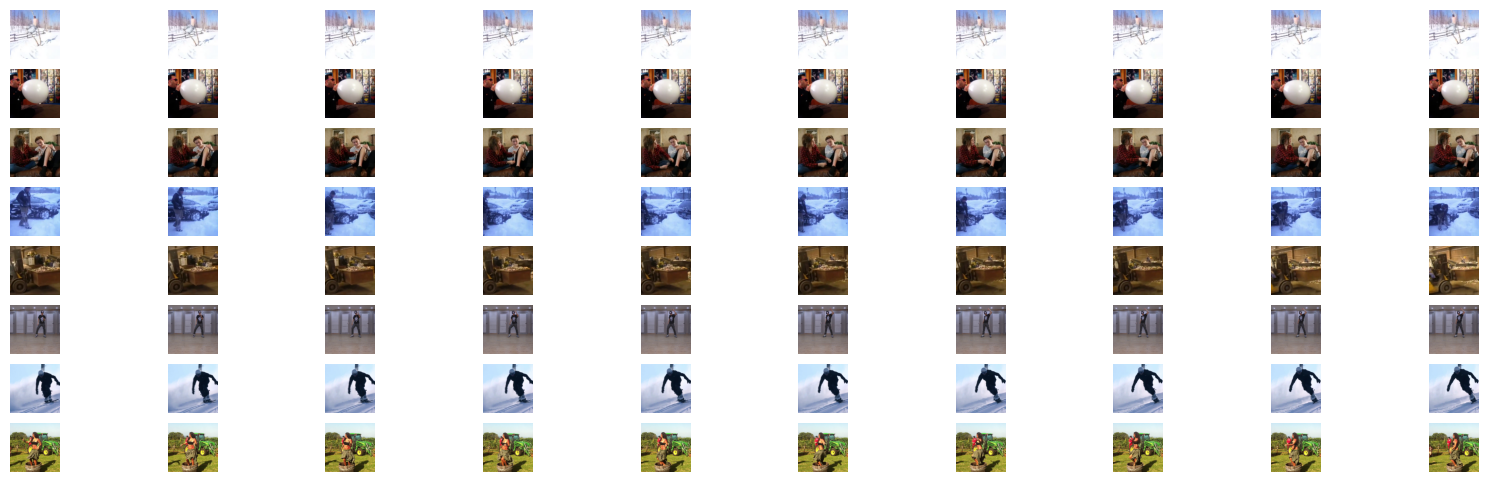

In [8]:
if args.test_modules:
    h_w_rgb_frame = batch[1, 50, :, :, :] # batch, frame, height, width, rgb 
    # plot 
    import matplotlib.pyplot as plt
    # plt.imshow(h_w_rgb_frame)


    # grid of 3x10 frames, 3 rows, 10 columns, one row per batch element and 10 frames per batch element (evenly spaced)
    print("Batch size: ", args.batch_size)
    print("batch shape: ", batch.shape)
    assert batch.shape[1] == args.batch_size
    fig, ax = plt.subplots(args.batch_size, 10, figsize=(20, 6))
    for i in range(args.batch_size):
        for j in range(10):
            # batch has shape [num_frames, batch_size, channels, height, width]
            # we gotta visualize [height, width, channels] with imshow
            ax[i, j].imshow(batch[j*5, i, :, :, :].transpose(1, 2, 0))
            ax[i, j].axis('off')
    # save ultra high res pic in case we need it
    plt.savefig('video_data.png', dpi=300)
    plt.show()

## CeNN Model
 - `cenn_params = (conv_layers, args={'kernel_size': 3, 'num_updates_per_frame': 10, 'activation_reg': 1.0})`
 - `dPhi(cenn_params, Phi)`: Takes the tuple of dicts representing the CeNN params (conv layers) and Phi, where Phi has shape `[batch, channels, height, width]`
 - `run_model(cenn_params, Phi, video_seq, n_frames, rec_period=1, full_state_tensor=True)`: Runs the Scotopic NCA model on a bunch of frames in a row. 

In [9]:
def init_cenn_params(rng_key,
                    kernel_size=3, 
                    in_channels=16,
                    out_channels=16,
                    num_percept_kernels=2, 
                    hidden_layers=[64, 128], 
                    dt = 0.1, 
                    drain = -0.01, 
                    sparsify_frac=0.9, 
                    activation='tanh'):
    """ Initialize the parameters of the CENN model. 

    Creates num_percept_kernels of size kernel_size x kernel_size x in_channels,
    concatenates those into the new percept tensor, then runs a series of 1x1 convs 
    with hidden_layers number of channels each, finally outputting a tensor of size
    [batch, in_channels, height, width].

    Input: phi tensor [batch, in_channels, height, width]
    """
    conv_i_key = jax.random.split(rng_key)[0]
    conv_params = []

    # first conv layer for percept kernels
    # OIHW (out_ch, in_ch, height, width)
    conv_params.append({
        'weights': jax.random.uniform(conv_i_key, 
                                        (num_percept_kernels, in_channels, kernel_size, kernel_size),
                                        minval=-1, 
                                        maxval=1) * (jnp.sqrt(6/(in_channels + num_percept_kernels))),
        'bias': jax.random.uniform(conv_i_key, (1, num_percept_kernels, 1, 1)) / num_percept_kernels
    })

    # add hidden layers
    hidden_layers = [num_percept_kernels] + hidden_layers
    for i in range(len(hidden_layers)-1): 
        i=i+1
        conv_i_key = jax.random.split(conv_i_key)[0]
        conv_params.append({
            'weights': jax.random.uniform(conv_i_key, 
                                        (hidden_layers[i], hidden_layers[i-1], 1, 1),
                                        minval=-1, 
                                        maxval=1) * (jnp.sqrt(6/(hidden_layers[i-1] + hidden_layers[i]))),
            'bias': jax.random.uniform(conv_i_key, (1, hidden_layers[i], 1, 1)) / hidden_layers[i]
        })
    
    # add final layer, mapping back to in_channels
    conv_i_key = jax.random.split(conv_i_key)[0]
    conv_params.append({
        'weights': jax.random.uniform(conv_i_key, 
                                        (out_channels, hidden_layers[-1], 1, 1),
                                        minval=-1, 
                                        maxval=1) * (jnp.sqrt(6/(hidden_layers[-1] + in_channels))),
        'bias': jax.random.uniform(conv_i_key, (1, out_channels, 1, 1)) / out_channels
    }) 
    args_ = {
        'kernel_size': kernel_size,
        'in_channels': in_channels,
        'num_percept_kernels': num_percept_kernels,
        'hidden_layers': hidden_layers,
        'activation': activation,
        'output_activation': 'sigmoid', 
        'dt': dt, 
        'drain': drain, 
        'sparsify_frac': sparsify_frac, 
        'random_seed': jax.random.randint(conv_i_key, (1,), 0, 1000)[0],
        'random_key': jax.random.split(conv_i_key)[0]
    }
    return conv_params, args_

# define the forward pass, using tanh activation
def cenn_forward(params, x):
    """ Forward pass of the CENN model. 

    Input: params, a list of dictionaries containing the weights and biases of each layer
    Input: x, the input tensor of shape [batch, channels, height, width]
    """
    conv_params, args_ = params

    for i, layer in enumerate(conv_params):
        # print(f"Layer {i}: ")
        # print(f"\tx.shape: ", x.shape)
        # print(f"\tweights.shape: ", layer['weights'].shape)
        x = jax.lax.conv_general_dilated(x, 
                                         layer['weights'], 
                                         window_strides=(1, 1), 
                                         padding='SAME') + layer['bias']
        if args_['activation'] == 'tanh' and i < len(conv_params)-1:
            x = jnp.tanh(x)
        elif args_['activation'] == 'relu' and i < len(conv_params)-1:
            x = jax.nn.relu(x)
        elif args_['activation'] == 'sigmoid' and i < len(conv_params)-1:
            x = jax.nn.sigmoid(x)
        elif args_['output_activation'] == 'tanh' and i == len(conv_params)-1:
            x = jnp.tanh(x)
        elif args_['output_activation'] == 'relu' and i == len(conv_params)-1:
            x = jax.nn.relu(x)
        elif args_['output_activation'] == 'sigmoid' and i == len(conv_params)-1:
            x = jax.nn.sigmoid(x)
        else:
            raise ValueError("Invalid activation function specified.")
    return x



In [10]:
# make a random starting tensor of shape args.batch_size x args.Phi_dim x args.height_px x args.width_px
Phi = jax.random.uniform(jax.random.PRNGKey(0), (args.batch_size, args.Phi_dim, args.height_px, args.width_px))
# check device
print("Phi device: ", Phi.devices())
print("Phi shape: ", Phi.shape)

# load a video tensor from the generator
video_tensor = next(video_data_generator(train_mp4s, args.batch_size, rescale=[args.height_px, args.width_px], float01=True))
# check device
print("Video tensor device: ", video_tensor.devices())
print("Video tensor shape: ", video_tensor.shape)

# initialize some weights for the cenn
# takes in Phi + RGB frame (sparsified) [batch, Phi_dim + 3, height, width], outputs dPhi [batch, Phi_dim, height, width]
cenn_params = init_cenn_params(jax.random.PRNGKey(args.random_seed),
                                kernel_size=args.kernel_size,
                                in_channels=args.Phi_dim+3,
                                out_channels=args.Phi_dim,
                                num_percept_kernels=args.num_percept_kernels,
                                hidden_layers=[64, 128],
                                dt=args.dt, 
                                drain = args.drain, 
                                activation= args.activation)

# run on single frame 
print("\nTest forward pass on zero-valued frame with random init Phi")
dPhi = cenn_forward(cenn_params, jnp.concatenate([Phi, video_tensor[0, :, :, :, :]], axis=1))
print('dPhi shape: ', dPhi.shape)
print(cenn_params[1])

Phi device:  {cuda(id=0)}
Phi shape:  (8, 16, 128, 128)


Video tensor device:  {cuda(id=0)}
Video tensor shape:  (296, 8, 3, 128, 128)

Test forward pass on zero-valued frame with random init Phi
dPhi shape:  (8, 16, 128, 128)
{'kernel_size': 5, 'in_channels': 19, 'num_percept_kernels': 2, 'hidden_layers': [2, 64, 128], 'activation': 'relu', 'output_activation': 'sigmoid', 'dt': 0.25, 'drain': -0.0, 'sparsify_frac': 0.9, 'random_seed': Array(875, dtype=int32), 'random_key': Array([1460458049, 1600254298], dtype=uint32)}


In [11]:
# define iterated forward pass with lax.scan
def cenn_forward_iter(params, video_tensor, Phi):
    """ Forward pass of the CENN model, iterated num_iters times. 
    `params`: tuple of dicts from `init_cenn_params()`. 
    `video_tensor`: tensor of shape [num_frames, batch, channels, height, width]
    `Phi`: tensor of shape [batch, channels, height, width]
    """
    conv_params, args_ = params
    args_['random_key'] = jax.random.split(args_['random_key'])[0]
    sparsify_video = args_['sparsify_frac']
    dt = args_['dt']
    # check that video_tensor and Phi match on batch dimension
    assert video_tensor.shape[1] == Phi.shape[0]
    if sparsify_video: 
        sparse_tensor = jax.random.bernoulli(args_['random_key'], 1-sparsify_video, video_tensor.shape)
        # print("Sparse tensor shape: ", sparse_tensor.shape)
        # print("Sparse tensor type: ", sparse_tensor.dtype)
        # print("Sparse tensor sum: ", sparse_tensor.sum())
        video_tensor = video_tensor * sparse_tensor
    # print("Video tensor shape: ", video_tensor.shape)

    num_frames = video_tensor.shape[0]

    # define the scan function -- specify the output (Phi) and the carry (Phi)
    def scan_fn(carry, x):
        """ carry: previous iteration Phi state value 
        x: new video tensor input shape [batch, channels, height, width]

        The lax call iterates x thru video_tensor[frames, :, :, :, :]. 

        Return: new Phi value, prediction of current input Phi[:, :3, :, :]
        """
        Phi = carry
        Phi_x_conc = jnp.concatenate([Phi, x], axis=1)
        dPhi = cenn_forward(params, Phi_x_conc)

        preds = Phi[:, :3, :, :] # [batch, 3, height, width]
        # print("X shape: ", x.shape)
        # print("x dtype: ", x.dtype)
        
        zero_input_mask = (x!= 0)
        # print("Zero input mask shape: ", zero_input_mask.shape)
        # print("Zero input mask sum: ", zero_input_mask.sum())
        loss = preds*zero_input_mask - x*zero_input_mask
        # loss = mse 
        loss = loss * loss # element-wise square
        loss = loss.sum() / (zero_input_mask.sum() + 1e-6) # divide by number of non-zero elements
        hist_entry = {
            'loss': loss, 
            'pred_state': preds
        }

        return Phi + args_['dt'] * dPhi + args_['drain'] * Phi, hist_entry

    # run the scan function
    Phi_T, hist = jax.lax.scan(scan_fn, Phi, video_tensor) 

    return Phi_T, hist 

In [12]:
print("Video tensor shape: ", video_tensor.shape)
print("Phi shape: ", Phi.shape)
print("Args.drain: ", args.drain)
print("cenn_params[1]['drain']: ", cenn_params[1]['drain'])

Video tensor shape:  (296, 8, 3, 128, 128)
Phi shape:  (8, 16, 128, 128)
Args.drain:  -0.0
cenn_params[1]['drain']:  -0.0


In [13]:
# try out the iterated forward pass
Phi_T, hist = cenn_forward_iter(cenn_params, video_tensor, Phi)
print("\nPhi_T shape: ", Phi_T.shape)
print("Hist keys: ", hist.keys())
for key in hist.keys(): 
    print(f"\tShape of hist[{key}]: ", hist[key].shape)


Phi_T shape:  (8, 16, 128, 128)
Hist keys:  dict_keys(['loss', 'pred_state'])
	Shape of hist[loss]:  (296,)
	Shape of hist[pred_state]:  (296, 8, 3, 128, 128)


Text(0, 0.5, 'loss (mse)')

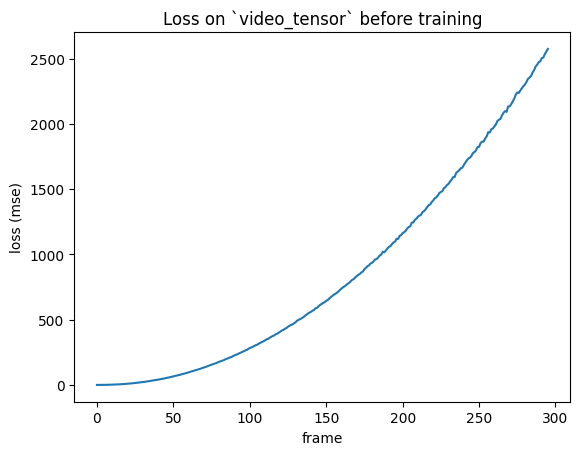

In [14]:
plt.plot(hist['loss'])
plt.title("Loss on `video_tensor` before training")
plt.xlabel('frame')
plt.ylabel('loss (mse)')

In [15]:
# loss function: mean squared error between first 3 dims of phi[t] and video_tensor[t]
def cenn_loss(cenn_params, cenn_hyperparams, video_tensor, Phi):
    """ Loss function for the CENN model. 

    Input: params, a list of dictionaries containing the weights and biases of each layer
    Input: video_tensor, the input tensor of shape [frames, batch, channels, height, width]
    Input: Phi, the tensor of shape [batch, channels, height, width]
    """
    final_Phi, hist = cenn_forward_iter((cenn_params, cenn_hyperparams), video_tensor, Phi)

    return jnp.mean(hist['loss'])

# try the loss function
cenn_loss(cenn_params[0], cenn_params[1], video_tensor, Phi)

Array(845.7747, dtype=float32)

# Simple Training Loop

Let's make a simple training loop to overfit the params to the `video_tensor` 
we have extracted as the first batch. We will record the mean loss over each 
iteratiion to show convergence, then visualize the state tensor evolution as a 
video for each memeber of the batch. 

In [16]:
losses =[]
cenn_params = init_cenn_params(jax.random.PRNGKey(args.random_seed),
                                kernel_size=args.kernel_size,
                                in_channels=args.Phi_dim+3,
                                out_channels=args.Phi_dim,
                                num_percept_kernels=args.num_percept_kernels,
                                hidden_layers=args.hidden_dims,
                                dt=args.dt, 
                                drain = args.drain)

In [17]:
def update_params(params, grads, lr): 
    return jax.tree.map(lambda p, g: p - lr * g, params, grads)

grad_fn = jax.grad(cenn_loss)

def overfit_cenn(params, video_tensor, num_iters=100, eval_period=1, lr=1e-3):
    """ Overfit the CENN model to a single batch of video data. 

    params: a list of dictionaries containing the weights and biases of each layer
    video_tensor: the input tensor of shape [frames, batch, channels, height, width]
    Phi: the initial tensor of shape [batch, channels, height, width]
    num_iters: the number of iterations to train for
    lr: the learning rate for the optimizer
    """
    Phi_0 = jnp.zeros([args.batch_size, args.Phi_dim, args.height_px, args.width_px])
    print("Phi 0 shape and batch_size: ", Phi_0.shape, args.batch_size)
    losses = []

    pbar = tqdm(range(num_iters))
    for i in pbar:
        # print("A: Phi_0: ", Phi_0[:3, :3, :3, :3])
        grads = grad_fn(params[0], params[1], video_tensor, Phi_0)
        # print("B: Phi_0: ", Phi_0[:3, :3, :3, :3])
        params_0_new = update_params(params[0], grads, lr)
        params = (params_0_new, params[1])
        if i % eval_period == 0:
            loss = cenn_loss(params[0], params[1], video_tensor, Phi_0)
            losses.append(loss)
            # print("C: Phi_0: ", Phi_0[:3, :3, :3, :3])
            # set pbar 
            pbar.set_postfix({'Loss': loss})
        
        Phi_0 = jnp.zeros([args.batch_size, args.Phi_dim, args.height_px, args.width_px])
    
    return losses, params, Phi_0

def overfit_cenn_adam(params, video_tensor, num_iters=100, eval_period=1, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    """Overfit the CENN model to a single batch of video data using Adam optimizer.

    params: a list of dictionaries containing the weights and biases of each layer
    video_tensor: the input tensor of shape [frames, batch, channels, height, width]
    Phi: the initial tensor of shape [batch, channels, height, width]
    num_iters: the number of iterations to train for
    lr: the learning rate for the optimizer
    beta1: exponential decay rate for the first moment estimates
    beta2: exponential decay rate for the second moment estimates
    eps: a small constant for numerical stability
    """
    Phi_0 = jnp.zeros([args.batch_size, args.Phi_dim, args.height_px, args.width_px])
    print("Phi 0 shape and batch_size: ", Phi_0.shape, args.batch_size)

    losses = []
    pbar = tqdm(range(num_iters))

    # Initialize Adam optimizer parameters
    m0 = jax.tree.map(lambda x: jnp.zeros_like(x), params[0])
    v0 = jax.tree.map(lambda x: jnp.zeros_like(x), params[0])
    t = 0

    for i in pbar:
        t += 1
        grads = grad_fn(params[0], params[1], video_tensor, Phi_0)

        # Update Adam optimizer parameters
        m0 = jax.tree.map(lambda m, g: beta1 * m + (1 - beta1) * g, m0, grads)
        v0 = jax.tree.map(lambda v, g: beta2 * v + (1 - beta2) * g**2, v0, grads)
        mhat = jax.tree.map(lambda m: m / (1 - beta1**t), m0)
        vhat = jax.tree.map(lambda v: v / (1 - beta2**t), v0)

        # Update model parameters using Adam
        params_0_new = jax.tree.map(lambda p, m, v: p - lr * m / (jnp.sqrt(v) + eps), params[0], mhat, vhat)
        params = (params_0_new, params[1])

        if i % eval_period == 0:
            loss = cenn_loss(params[0], params[1], video_tensor, Phi_0)
            losses.append(loss)
            pbar.set_postfix({'Loss': loss})

    Phi_0 = jnp.zeros([args.batch_size, args.Phi_dim, args.height_px, args.width_px])
    return losses, params, Phi_0



    

# try the overfitting function
print(f"Training at {args.lr}...")
# losses_, cenn_params, Phi_0 = overfit_cenn(cenn_params, video_tensor, num_iters=500, lr=args.lr)
losses_, cenn_params, Phi_0 = overfit_cenn_adam(cenn_params, video_tensor, num_iters=500, lr=args.lr)
losses += losses_
# print(f"Training at {args.lr/2}...")
# losses_, cenn_params, Phi_0 = overfit_cenn(cenn_params, video_tensor, num_iters=100, lr=args.lr*2)
# losses += losses_
# print(f"Training at {args.lr/4}...")
# losses_, cenn_params, Phi_0 = overfit_cenn(cenn_params, video_tensor, num_iters=200, lr=args.lr*4)

Training at 0.005...
Phi 0 shape and batch_size:  (8, 16, 128, 128) 8


  0%|          | 0/500 [00:00<?, ?it/s]

2024-04-06 01:57:00.241362: W external/xla/xla/service/hlo_rematerialization.cc:2946] Can't reduce memory use below -3.22GiB (-3461237432 bytes) by rematerialization; only reduced to 62.60GiB (67218960988 bytes), down from 62.61GiB (67229321844 bytes) originally
2024-04-06 01:57:10.450523: W external/tsl/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.75GiB (rounded to 2948595712)requested by op 
2024-04-06 01:57:10.450826: W external/tsl/tsl/framework/bfc_allocator.cc:494] *************************************************************************************************___
E0406 01:57:10.451057   80302 pjrt_stream_executor_client.cc:2809] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2948595712 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  452.04MiB
              constant allocation:         4B
        maybe_live_out allocation:   62.45GiB
  

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2948595712 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  452.04MiB
              constant allocation:         4B
        maybe_live_out allocation:   62.45GiB
     preallocated temp allocation:  161.00MiB
  preallocated temp fragmentation:         0B (0.00%)
                 total allocation:   63.04GiB
Peak buffers:
	Buffer 1:
		Size: 18.50GiB
		Operator: op_name="jit(scan)/jit(main)/while/body/dynamic_update_slice" source_file="/tmp/ipykernel_80302/3902912479.py" source_line=56
		XLA Label: fusion
		Shape: f32[296,8,128,128,128]
		==========================

	Buffer 2:
		Size: 18.50GiB
		Operator: op_name="jit(scan)/jit(main)/while/body/dynamic_update_slice" source_file="/tmp/ipykernel_80302/3902912479.py" source_line=56
		XLA Label: fusion
		Shape: f32[296,8,128,128,128]
		==========================

	Buffer 3:
		Size: 9.25GiB
		Operator: op_name="jit(scan

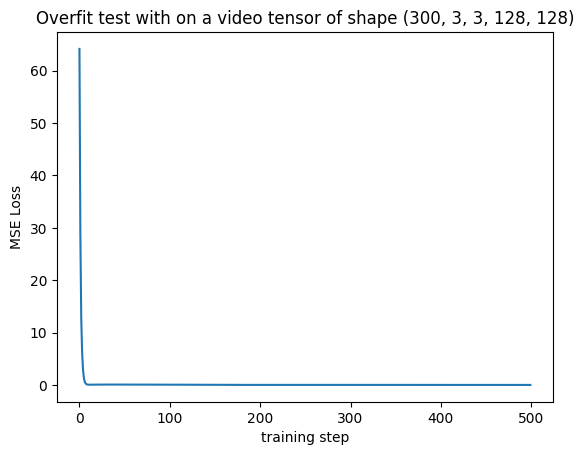

In [ ]:
plt.plot(losses)
plt.title(f"Overfit test with on a video tensor of shape {video_tensor.shape}")
plt.xlabel("training step")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
# run a phi thru at inference 
Phi_0 = jnp.zeros([args.batch_size, args.Phi_dim, args.height_px, args.width_px])
Phi_T, hist = cenn_forward_iter(cenn_params, video_tensor, Phi_0)
print("Phi_T shape: ", Phi_T.shape)
print("Hist keys: ", hist.keys())

Phi_T shape:  (3, 16, 128, 128)
Hist keys:  dict_keys(['loss', 'pred_state'])


In [ ]:
hist['pred_state'].shape

(300, 3, 3, 128, 128)

In [ ]:

# export a video with cv2
def store_video(hist_tensor, out_name='out34.mp4', batch_idx=0, pixelnorm='rescale'): 
    """ hist_tensor has shape [frames, batch, channels, height, width]
    pixelnorm is either 'rescale' or 'clip' or 'sigmoid'
    """
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    # mp4 video writer
    out = cv2.VideoWriter(out_name, fourcc, 30, (hist_tensor.shape[-1], hist_tensor.shape[-2]))
    for i in tqdm(range(hist_tensor.shape[0])):
        frame = hist_tensor[i, batch_idx, :, :, :].transpose(1, 2, 0)
        frame = frame[:, :, :3]
        # ensure frame is float between 0 and 1
        if pixelnorm == 'rescale': 
            frame = (frame - frame.min()) / (frame.max() - frame.min())
        elif pixelnorm == 'clip':
            frame = np.clip(frame, 0, 1)
        elif pixelnorm == 'sigmoid': 
            frame = 1 / (1 + np.exp(-frame))
        else: 
            raise ValueError("Invalid pixelnorm specified.")
        # scale to 0-255
        frame = (frame*255).astype(np.uint8)

        # print("Frame size: ", frame.shape)
        out.write(np.array(frame))
    out.release()

batch_size = hist['pred_state'].shape[1]
for i in range(batch_size):
    out_path = os.path.join('overfit', f'overfit_{i}.mp4')
    # mkdir 
    # os.mkdir('overfit')
    store_video(hist['pred_state'], out_name=out_path, batch_idx=i, pixelnorm='clip')


100%|██████████| 300/300 [00:00<00:00, 812.73it/s]


In [ ]:
hist['loss'].mean()

Array(0.06051895, dtype=float32)

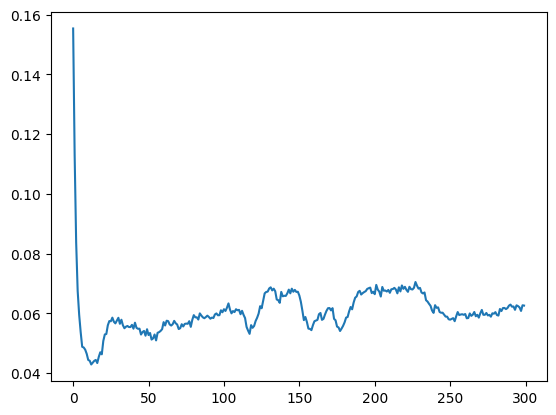

In [ ]:
plt.plot(hist['loss'])